In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# data preprocessing
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [65]:
df = pd.read_csv(r'../data/email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
df.shape

(5573, 2)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [68]:
df.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [69]:
#  Nội dung email bị trùng
so_luong_trung = df['Message'].duplicated().sum()

print(f"Số dòng có nội dung bị trùng: {so_luong_trung}")

Số dòng có nội dung bị trùng: 415


In [70]:
df = df.drop_duplicates()

In [71]:
df["Category"].value_counts()
df = df.drop(df[df["Category"] == '{"mode":"full"'].index)

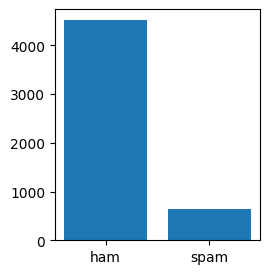

In [72]:

plt.figure(figsize=(9, 3))

plt.subplot(131)
plt.bar(df["Category"].unique(), df["Category"].value_counts().values)
plt.show()

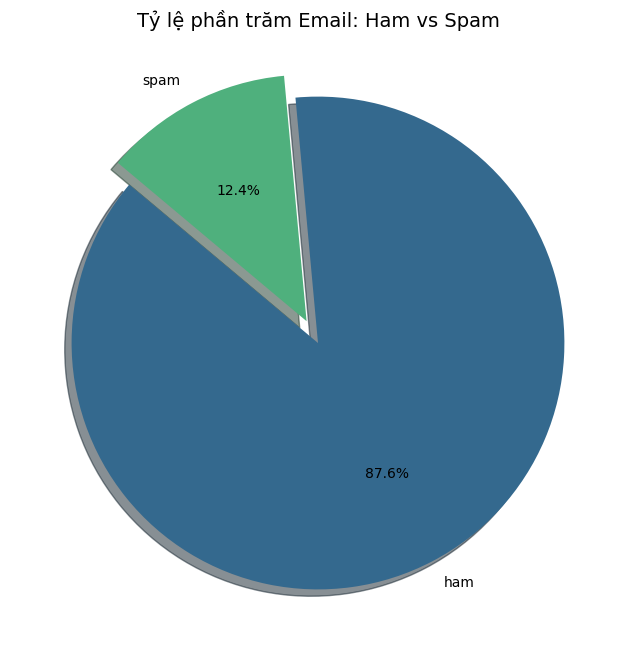

In [73]:
plt.figure(figsize=(8, 8))
plt.pie(
    df["Category"].value_counts(), 
    labels= df["Category"].unique(),      
    autopct='%1.1f%%',              
    startangle=140,                 
    colors=['#34698e', '#4fb07d'],  
    explode=(0, 0.1),               
    shadow=True                     
)

plt.title('Tỷ lệ phần trăm Email: Ham vs Spam', fontsize=14)
plt.show()

In [74]:
df["Length"] = df["Message"].apply(len)
df['num_words'] = df["Message"].apply(word_tokenize).apply(len)
df['num_sentence'] = df["Message"].apply(sent_tokenize).apply(len)

In [75]:
df.head()

,Category,Message,Length,num_words,num_sentence
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


Độ dài trung bình của các Emails Spam: 137.1185647425897
Độ dài trung bình của các Emails Ham: 70.86935341009743


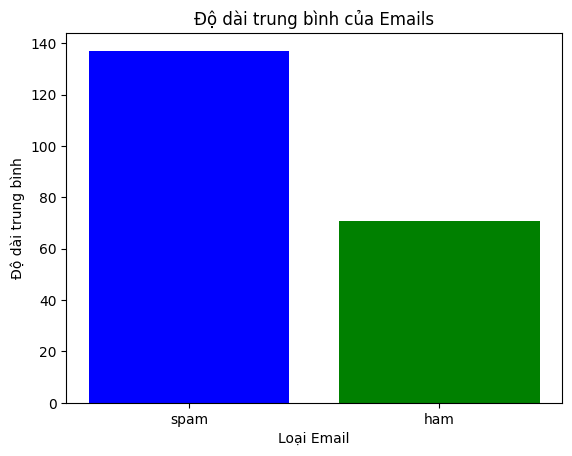

In [76]:
avg_lenght_spam =df[df['Category'] == "spam"]['Length'].mean()
avg_lenght_ham =df[df['Category'] == "ham"]['Length'].mean()

print("Độ dài trung bình của các Emails Spam:", avg_lenght_spam)
print("Độ dài trung bình của các Emails Ham:", avg_lenght_ham)

plt.bar(['spam', 'ham'], [avg_lenght_spam, avg_lenght_ham], color=['Blue', 'green'])
plt.title("Độ dài trung bình của Emails")
plt.xlabel("Loại Email")
plt.ylabel("Độ dài trung bình")
plt.show()

Số từ trung bình có trong các Emails Spam: 27.66770670826833
Số từ trung bình có trong các Emails Ham: 17.268157661647475


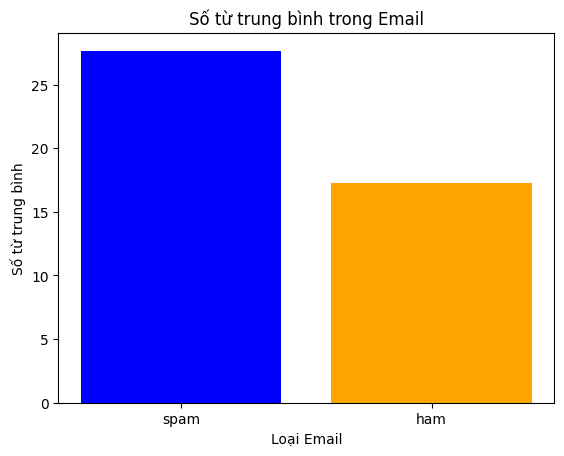

In [77]:
avg_word_ham =df[df['Category'] == "ham"]['num_words'].mean()
avg_word_spam =df[df['Category'] == "spam"]['num_words'].mean() 

print("Số từ trung bình có trong các Emails Spam:", avg_word_spam)
print("Số từ trung bình có trong các Emails Ham:", avg_word_ham)

plt.bar(['spam', 'ham'], [avg_word_spam, avg_word_ham], color=['Blue', 'orange'])
plt.title("Số từ trung bình trong Email")
plt.xlabel("Loại Email")
plt.ylabel("Số từ trung bình")
plt.show()

Số câu trung bình trong các Emails Spam: 2.9703588143525743
Số câu trung bình trong các Emails Ham: 1.8277236492471214


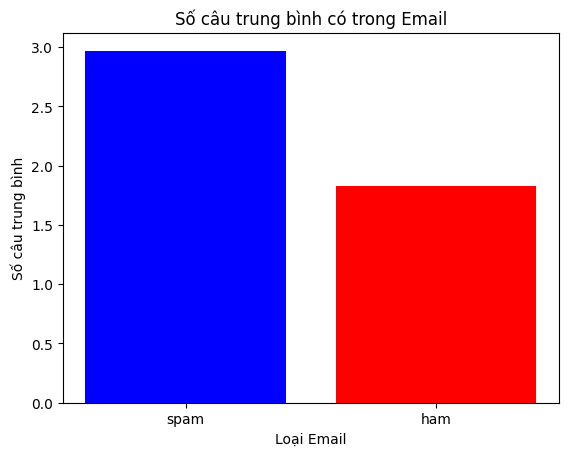

In [78]:
avg_word_spam =df[df['Category'] == "spam"]['num_sentence'].mean()
avg_word_ham =df[df['Category'] == "ham"]['num_sentence'].mean()

print("Số câu trung bình trong các Emails Spam:", avg_word_spam)
print("Số câu trung bình trong các Emails Ham:", avg_word_ham)

plt.bar(['spam', 'ham'], [avg_word_spam, avg_word_ham], color=['Blue', 'red'])
plt.title("Số câu trung bình có trong Email")
plt.xlabel("Loại Email")
plt.ylabel("Số câu trung bình")
plt.show()

Mối Quan hệ giữa các đặc trưng:                 Length  num_words  num_sentence
Length        1.000000   0.966141      0.622428
num_words     0.966141   1.000000      0.679418
num_sentence  0.622428   0.679418      1.000000


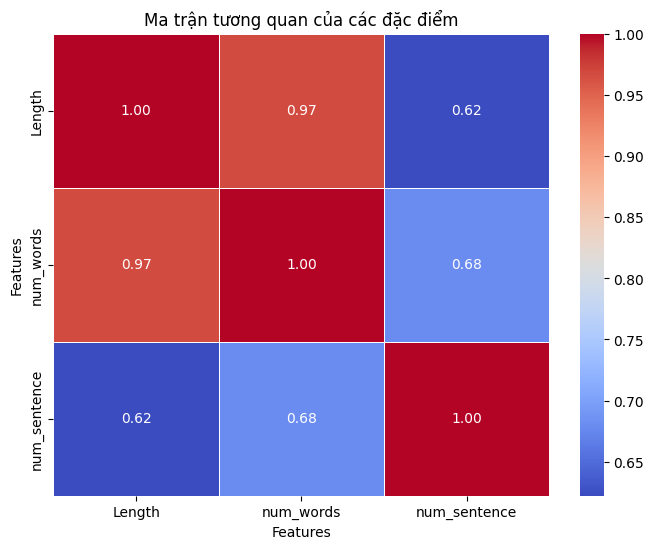

In [79]:
correlation_matrix = df[['Length', 'num_words', 'num_sentence']].corr()
print("Mối Quan hệ giữa các đặc trưng:", correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan của các đặc điểm')
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

In [80]:
df.head()

,Category,Message,Length,num_words,num_sentence
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [81]:
def clean_email_spam(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    words = [word for word in text.split() if len(word) > 1]
    return " ".join(words)
df.loc[df['Category'] == 'ham', 'Message'] = df.loc[df['Category'] == 'ham', 'Message'].apply(clean_email_spam)

In [82]:
df['transform_text'] = df['Message'].str.lower()

# Tokenization: tách từ, chia văn bản dài thành các đơn vị nhỏ hơn "tokens"
df['transform_text'] = df['transform_text'].apply(word_tokenize)

# Removing stop words and punctuation: Loại bỏ từ dừng và dấu câu
stop_words = set(stopwords.words('english'))
df['transform_text'] = df['transform_text'].apply(lambda x:[word for word in x if word not in stop_words and word not in string.punctuation])

# Stemming: Đưa các từ về dạng gốc (root form) bằng cách cắt bỏ các phần hậu tố vd [running, runs] -> [run, run]
ps = PorterStemmer()
df['transform_text'] = df['transform_text'].apply(lambda x: [ps.stem(word) for word in x])

# Convert the preprocessed text back to string
df['transform_text'] = df['transform_text'].apply(lambda x: ' '.join(x))

In [83]:
df.head()

,Category,Message,Length,num_words,num_sentence,transform_text
0,ham,Go until jurong point crazy Available only in ...,111,24,2,go jurong point crazi avail bugi great world l...
1,ham,Ok lar Joking wif oni,29,8,2,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,dun say so early hor already then say,49,13,1,dun say earli hor alreadi say
4,ham,Nah don think he goes to usf he lives around h...,61,15,1,nah think goe usf live around though


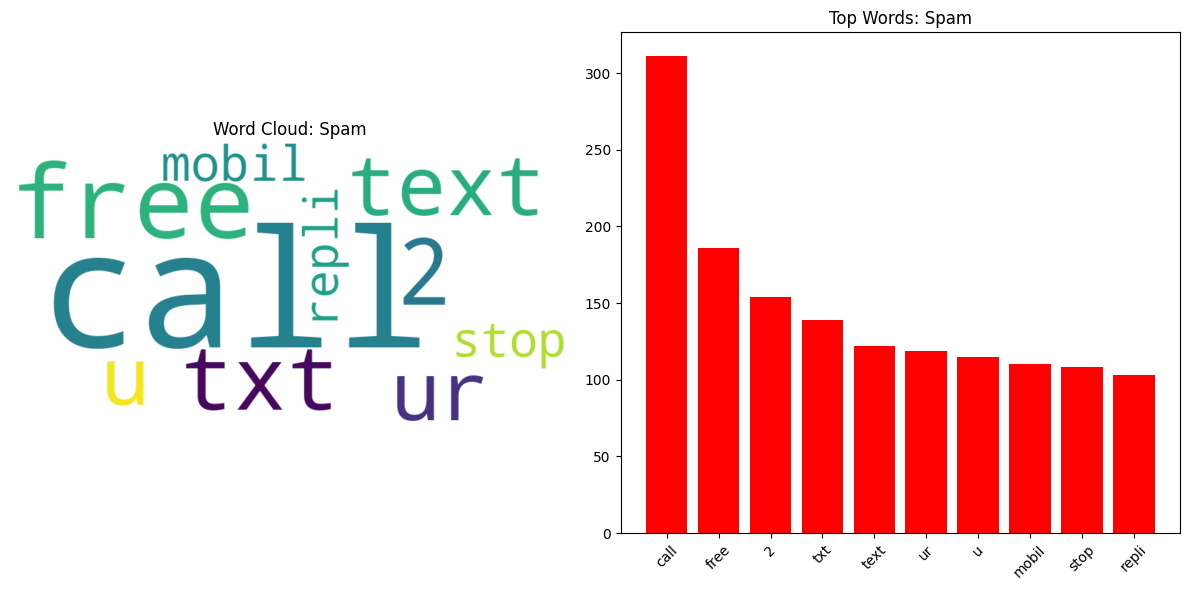

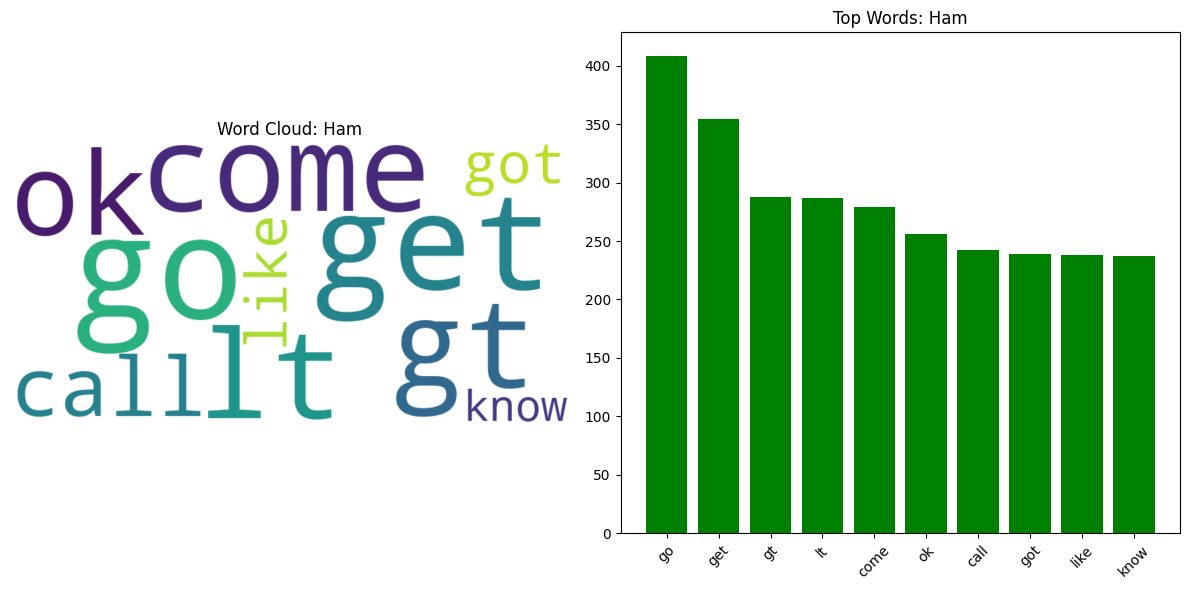

In [84]:
def plot_word_analysis(emails_series, title_suffix, color='orange'):
    # Tokenize and count
    words = ' '.join(emails_series).split()
    word_counts = Counter(words)
    most_common = word_counts.most_common(10)
    
    # Extract data for plotting
    words_list, counts = zip(*most_common)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    # Word Cloud
    plt.subplot(1, 2, 1)
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(most_common))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Word Cloud: {title_suffix}')
    plt.axis('off')
    
    # Bar Chart
    plt.subplot(1, 2, 2)
    plt.bar(words_list, counts, color=color)
    plt.title(f'Top Words: {title_suffix}')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_word_analysis(df[df['Category'] == "spam"]['transform_text'], "Spam", color='red')
plot_word_analysis(df[df['Category'] == "ham"]['transform_text'], "Ham", color='green')

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})
X = df["Message"]
y = df["Category"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_val =vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(3300, 6729)
(825, 6729)
(1032, 6729)


In [86]:
y_train.value_counts().values

array([2890,  410])

In [88]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42,)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

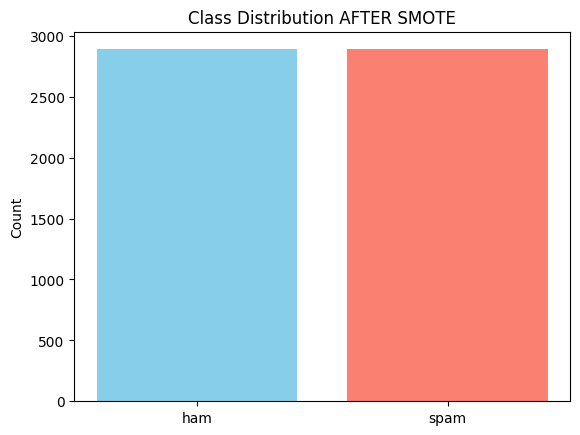

In [89]:
plt.bar(y_train_res.value_counts().index, y_train_res.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['ham', 'spam'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [90]:
y_train_res.value_counts().values

array([2890, 2890])

In [91]:
import numpy as np

def compute_Sigmoid(x):
    return 1/(1 + np.exp(-x))

# Loss function: binary cross entropy
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    # Avoid log(0) by clipping values
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# compute f-1 score, recall, precision
def compute_evaluation(TP, FP, FN):
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1_score = 2*(precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return f1_score, recall, precision

class LogisticRegressionCL:
    def __init__(self, learning_rate=0.5, n_iters=2000):
        self.lr=learning_rate
        self.n_iters=n_iters
        self.w=None     
        self.b=None     
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for i in range(self.n_iters):
            # compute z = X.w + b
            z = np.dot(X, self.w) + self.b
            
            y_pred = compute_Sigmoid(z)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            if i % 200 == 0:
                loss = compute_loss(y, y_pred)
                print(f"epoch = {i:>}/{self.n_iters}: loss = {loss:>4.4f}")
                
        return self.w, self.b
    
    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        y_pred = compute_Sigmoid(z)
        
        return (y_pred > 0.5).astype(int)
    
    def evaluate(self,X, y):
        y_pred = np.array(self.predict(X))
        y_true = np.array(y)
        
        report_data = {}
        for c in [0, 1]:
            tp = np.sum((y_pred == c) & (y_true == c))
            fp = np.sum((y_pred == c) & (y_true != c))
            fn = np.sum((y_pred != c) & (y_true == c))
            support = np.sum(y_true == c)
            
            f1, r, p = compute_evaluation(tp, fp, fn)
            report_data[c] = {"p": p, "r": r, "f1": f1, "sup": support}
            
        accuracy = np.sum(y_pred == y_true) / len(y_true)
        return report_data, accuracy
    
    def classification_Report(self, X, y):
        report_data, accuracy = self.evaluate(X, y)
        n_samples = len(y)

        print(f"\n{'':>15} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}\n")
        
        for label in [0, 1]:
            d = report_data[label]
            print(f"{str(label):>15} {d['p']:>10.2f} {d['r']:>10.2f} {d['f1']:>10.2f} {d['sup']:>10}")

        # Macro average
        macro_p = np.mean([report_data[0]['p'], report_data[1]['p']])
        macro_r = np.mean([report_data[0]['r'], report_data[1]['r']])
        macro_f1 = np.mean([report_data[0]['f1'], report_data[1]['f1']])
        
        print(f"{'accuracy':>15} {'':>10} {'':>10} {accuracy:>10.2f} {n_samples:>10}")
        print(f"{'macro avg':>15} {macro_p:>10.2f} {macro_r:>10.2f} {macro_f1:>10.2f} {n_samples:>10.2f}")
        
    

In [92]:
model_custom = LogisticRegressionCL()

model_custom.fit(X_train_res.toarray(), y_train_res)

print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
model_custom.classification_Report(X_val.toarray(), y_val)

print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
model_custom.classification_Report(X_test.toarray(), y_test)

epoch = 0/2000: loss = 0.6931
epoch = 200/2000: loss = 0.5179
epoch = 400/2000: loss = 0.4160
epoch = 600/2000: loss = 0.3508
epoch = 800/2000: loss = 0.3056
epoch = 1000/2000: loss = 0.2724
epoch = 1200/2000: loss = 0.2469
epoch = 1400/2000: loss = 0.2267
epoch = 1600/2000: loss = 0.2102
epoch = 1800/2000: loss = 0.1964

     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---

                 precision     recall   f1-score    support

              0       0.99       0.99       0.99        722
              1       0.93       0.95       0.94        103
       accuracy                             0.99        825
      macro avg       0.96       0.97       0.97     825.00

     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---

                 precision     recall   f1-score    support

              0       0.98       0.98       0.98        904
              1       0.84       0.84       0.84        128
       accuracy                             0.96       1032
      macro avg       0.91 

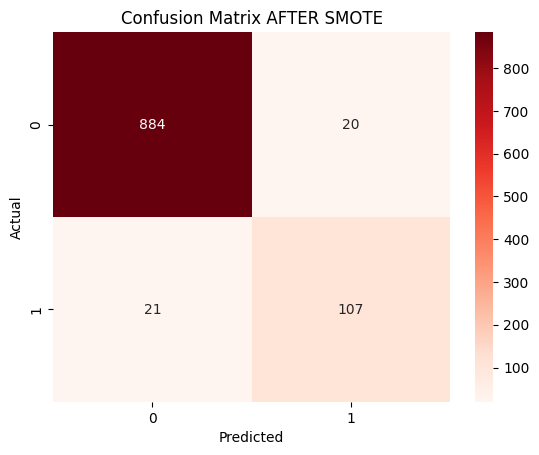

In [93]:
from sklearn.metrics import confusion_matrix
y_pred = model_custom.predict(X_test.toarray())
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [94]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_res.toarray(), y_train_res)

y_val_pred = model.predict(X_val.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
print(classification_report(y_val, y_val_pred))

y_test_pred = model.predict(X_test.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred))

     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       722
           1       0.95      0.96      0.96       103

    accuracy                           0.99       825
   macro avg       0.97      0.98      0.98       825
weighted avg       0.99      0.99      0.99       825

     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       904
           1       0.88      0.85      0.87       128

    accuracy                           0.97      1032
   macro avg       0.93      0.92      0.92      1032
weighted avg       0.97      0.97      0.97      1032



In [ ]:
feature_names = vectorizer.get_feature_names_out()

coefs = model.coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

feature_importance['abs_coef'] = feature_importance['coef'].abs()

top_20_features = feature_importance.sort_values(by='abs_coef', ascending=False).head(20)

top_20_features

,feature,coef,abs_coef
6148,txt,6.045880,6.045880
1395,call,5.490566,5.490566
5622,stop,4.450054,4.450054
3936,mobile,4.038120,4.038120
6640,www,3.873944,3.873944
4960,reply,3.839211,3.839211
2569,free,3.830654,3.830654
1583,claim,3.639853,3.639853
5878,text,3.523926,3.523926
266,150p,3.479315,3.479315


C:\Users\HP\AppData\Local\Temp\ipykernel_18348\1222663425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


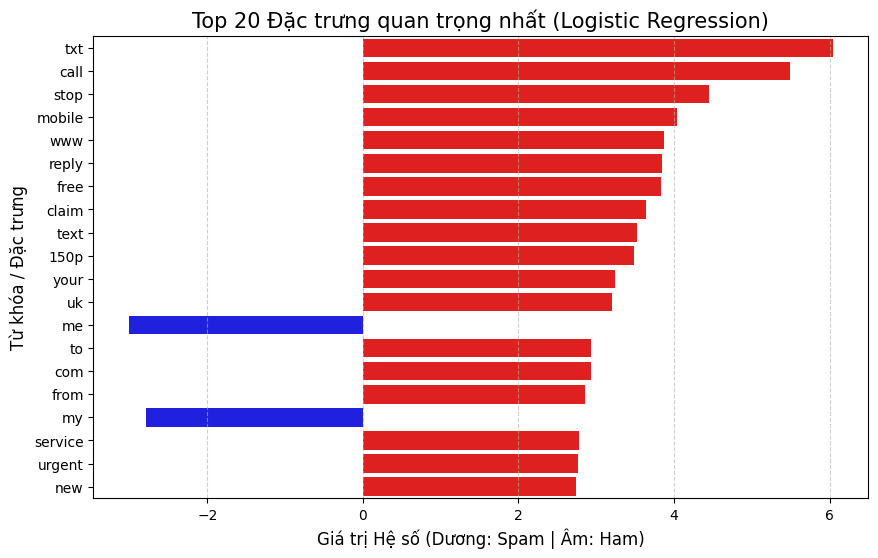

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['red' if c > 0 else 'blue' for c in top_20_features['coef']]

sns.barplot(
    x='coef', 
    y='feature', 
    data=top_20_features, 
    palette=colors
)

plt.title('Top 20 Đặc trưng quan trọng nhất (Logistic Regression)', fontsize=15)
plt.xlabel('Giá trị Hệ số (Dương: Spam | Âm: Ham)', fontsize=12)
plt.ylabel('Từ khóa / Đặc trưng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Navies_Bayes


In [ ]:
import numpy as np

class NaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:
            X_c = X[y == c]

            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0)
            self.prior[c] = X_c.shape[0] / X.shape[0]

    def gaussian(self, x, mean, var):
        eps = 1e-6
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(- (x - mean) ** 2 / (2 * var + eps))
        return coeff * exponent

    def predict(self, X):
        y_pred = []

        for x in X:
            scores = {}

            for c in self.classes:
                log_prior = np.log(self.prior[c])
                log_likelihood = np.sum(
                    np.log(self.gaussian(x, self.mean[c], self.var[c]))
                )

                scores[c] = log_prior + log_likelihood

            y_pred.append(max(scores, key=scores.get))

        return np.array(y_pred)

In [ ]:
model_nb = NaiveBayes()
model_nb.fit(X_train_res.toarray(), y_train_res)
print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
y_pred_val = model_nb.predict(X_val.toarray())
print(classification_report(y_val, y_pred_val))
print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
y_pred_test = model_nb.predict(X_test.toarray())
print(classification_report(y_test, y_pred_test))

In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train_res.toarray(), y_train_res)

y_val_pred = model.predict(X_val.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
print(classification_report(y_val, y_val_pred))

y_test_pred = model.predict(X_test.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred))

# SVM

In [ ]:
import numpy as np

class SVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        y_ = np.where(y <= 0, -1, 1)

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for i in range(n_samples):
                condition = y_[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(X[i], y_[i]))
                    self.b -= self.lr * (-y_[i])

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

In [ ]:
from models.svm import SVMCL
model_svm = SVM()
model_svm.fit(X_train_res.toarray(), y_train_res)
print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
y_pred_val = model_svm.predict(X_val.toarray())
print(classification_report(y_val, y_pred_val))

print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
y_pred_test = model_svm.predict(X_test.toarray())
print(classification_report(y_test, y_pred_test))


In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn import svm
model_svm = svm.SVC()
model_svm.fit(X_train_res.toarray(), y_train_res)
print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
y_pred_val = model_svm.predict(X_val.toarray())
print(classification_report(y_val, y_pred_val))

print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
y_pred_test = model_svm.predict(X_test.toarray())
print(classification_report(y_test, y_pred_test))

# Before Smote

# Logistic Regression

In [ ]:
model_custom = LogisticRegressionCL()

model_custom.fit(X_train.toarray(), y_train)

print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
model_custom.classification_Report(X_val.toarray(), y_val)

print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
model_custom.classification_Report(X_test.toarray(), y_test)

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = model_custom.predict(X_test.toarray())
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix BEFORE SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train.toarray(), y_train)

y_val_pred = model.predict(X_val.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
print(classification_report(y_val, y_val_pred))

y_test_pred = model.predict(X_test.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred))

# Navies Bayes

In [ ]:
model_nb = NaiveBayes()
model_nb.fit(X_train.toarray(), y_train)
print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
y_pred_val = model_nb.predict(X_val.toarray())
print(classification_report(y_val, y_pred_val))
print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
y_pred_test = model_nb.predict(X_test.toarray())
print(classification_report(y_test, y_pred_test))

In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix BEFORE SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train.toarray(), y_train)

y_val_pred = model.predict(X_val.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
print(classification_report(y_val, y_val_pred))

y_test_pred = model.predict(X_test.toarray())

print("     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred))

# SVM

In [ ]:
model_svm = SVM()
model_svm.fit(X_train.toarray(), y_train)
print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
y_pred_val = model_svm.predict(X_val.toarray())
print(classification_report(y_val, y_pred_val))

print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
y_pred_test = model_svm.predict(X_test.toarray())
print(classification_report(y_test, y_pred_test))

In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix BEFORE SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn import svm
model_svm = svm.SVC()
model_svm.fit(X_train.toarray(), y_train)
print("\n     --- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
y_pred_val = model_svm.predict(X_val.toarray())
print(classification_report(y_val, y_pred_val))

print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
y_pred_test = model_svm.predict(X_test.toarray())
print(classification_report(y_test, y_pred_test))